In [1]:
# Exploratory Data Analysis (EDA)

# Import required libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "application_train.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print("\nTarget distribution:")
print(df["TARGET"].value_counts())

Dataset shape: (307511, 122)

Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64


No Default: 91.93%
Default: 8.07%


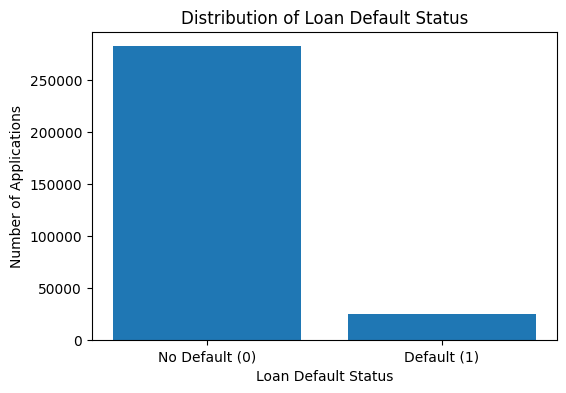

In [2]:
## Target Distribution
target_distribution = (df["TARGET"].value_counts(normalize=True).sort_index().mul(100))
target_distribution
print(f"No Default: {target_distribution[0]:.2f}%")
print(f"Default: {target_distribution[1]:.2f}%")

## Visualizing the target variable distribution.
plt.figure(figsize=(6,4))

target_counts = df["TARGET"].value_counts().sort_index()

plt.bar(["No Default (0)", "Default (1)"], target_counts.values)
plt.title("Distribution of Loan Default Status")
plt.ylabel("Number of Applications")
plt.xlabel("Loan Default Status")
plt.show()

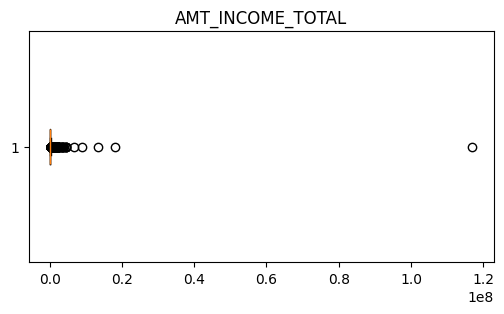

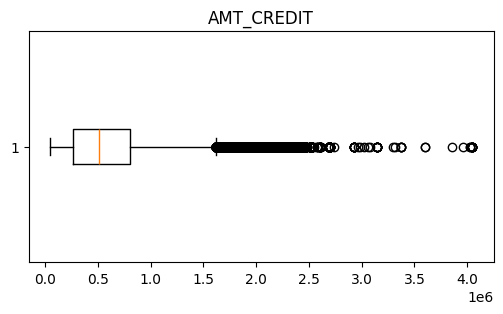

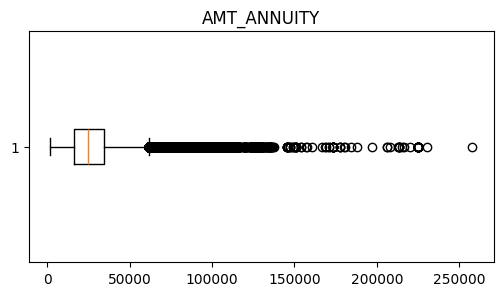

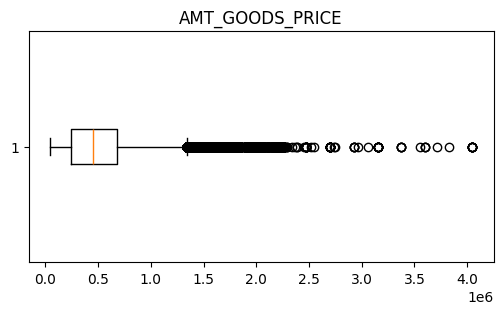

In [3]:
## Missing Values Analysis
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
missing_values.head(10)

## Missing Values Percentage
missing_percent=df.isnull().mean()*100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

missing_percent.head(10)

## Distribution of Numerical Variables
important_num=['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']
df[important_num].describe().T

## Checking for outliers in numerical variables using boxplots
for col in important_num:
    plt.figure(figsize=(6,3))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(col)
    plt.show()

Age summary:


count    307511.000000
mean         43.906900
std          11.947950
min          20.503765
25%          33.984942
50%          43.121150
75%          53.886379
max          69.073238
Name: DAYS_BIRTH, dtype: float64

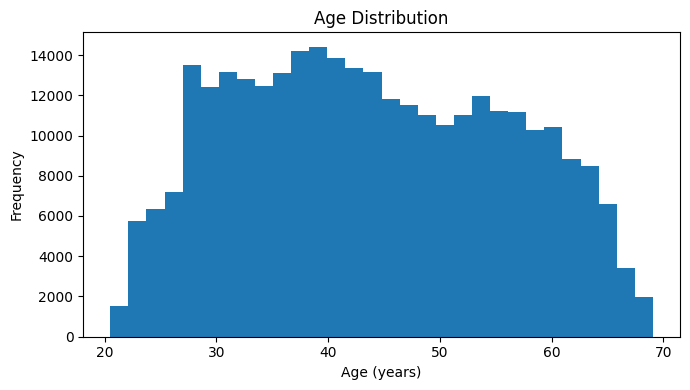

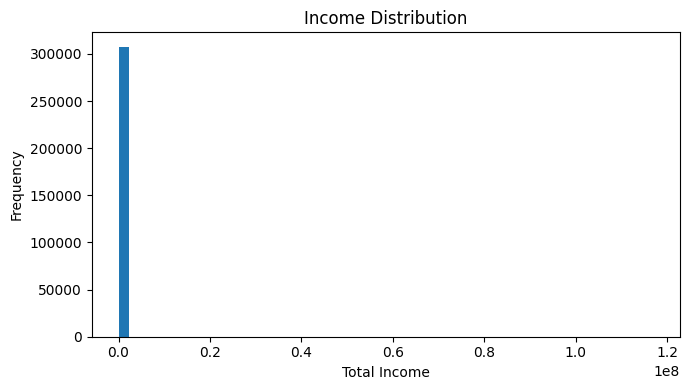

In [4]:
## Univariate Analysis

# Customer age
age_years = df["DAYS_BIRTH"].abs() / 365.25

print("Age summary:")
display(age_years.describe())

plt.figure(figsize=(7, 4))
plt.hist(age_years, bins=30)
plt.title("Age Distribution")
plt.xlabel("Age (years)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# Income distribution
plt.figure(figsize=(7, 4))
plt.hist(df["AMT_INCOME_TOTAL"].dropna(), bins=50)
plt.title("Income Distribution")
plt.xlabel("Total Income")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

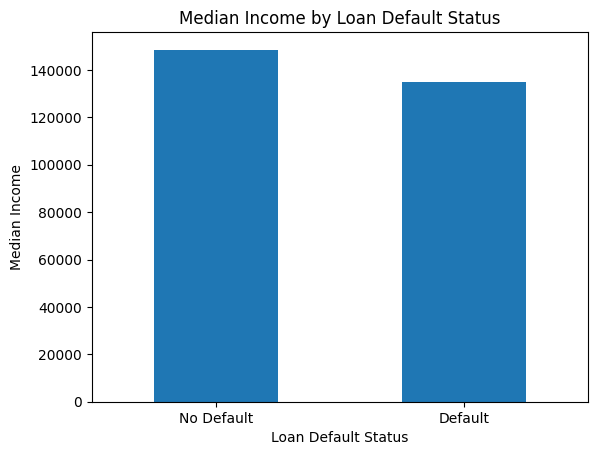

C:\Users\unive\AppData\Local\Temp\ipykernel_17876\3348430002.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  age_target = (df.assign(AGE_YEARS=age_years)


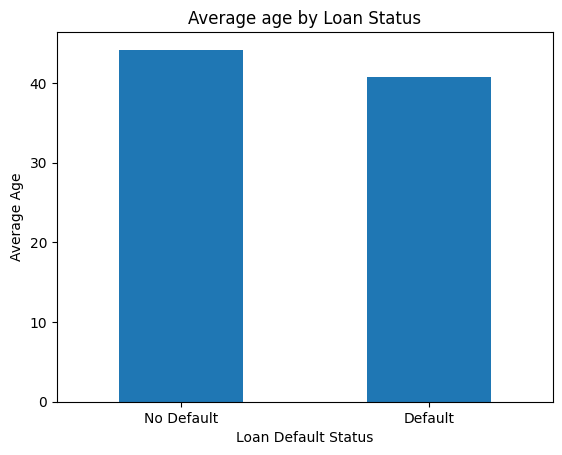

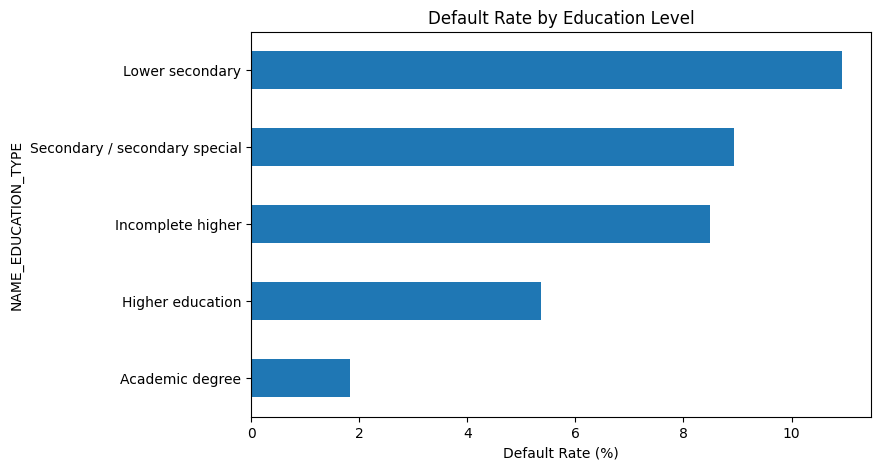

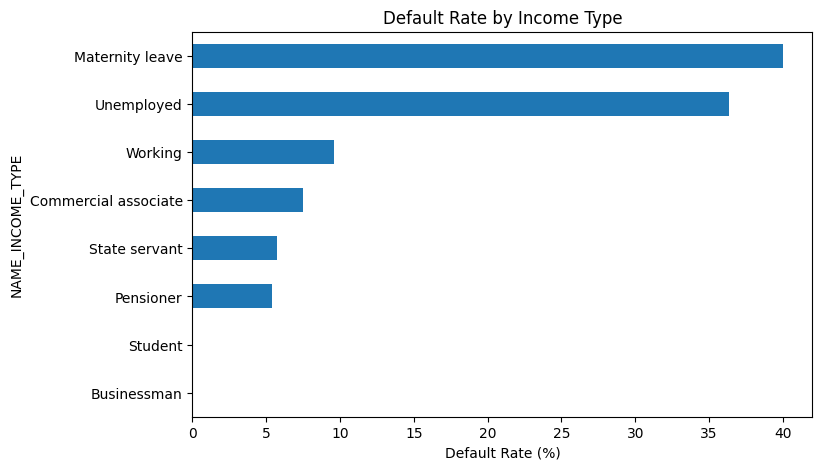

Infinite Values:
CREDIT_INCOME_RATIO     0
ANNUITY_INCOME_RATIO    0
TARGET                  0
dtype: int64
Missing Values:
CREDIT_INCOME_RATIO      0
ANNUITY_INCOME_RATIO    12
TARGET                   0
dtype: int64
Default rate by credit-to-income decile:


,count,mean
CREDIT_INCOME_BIN,,
"(0.00381, 1.332]",30759,6.908547
"(1.332, 1.818]",30780,7.761533
"(1.818, 2.266]",30730,8.112594
"(2.266, 2.764]",30772,9.021188
"(2.764, 3.265]",30725,8.654190
"(3.265, 3.906]",30741,9.196188
"(3.906, 4.725]",30754,8.616765
"(4.725, 5.769]",30751,7.950961
"(5.769, 7.488]",30815,7.441181


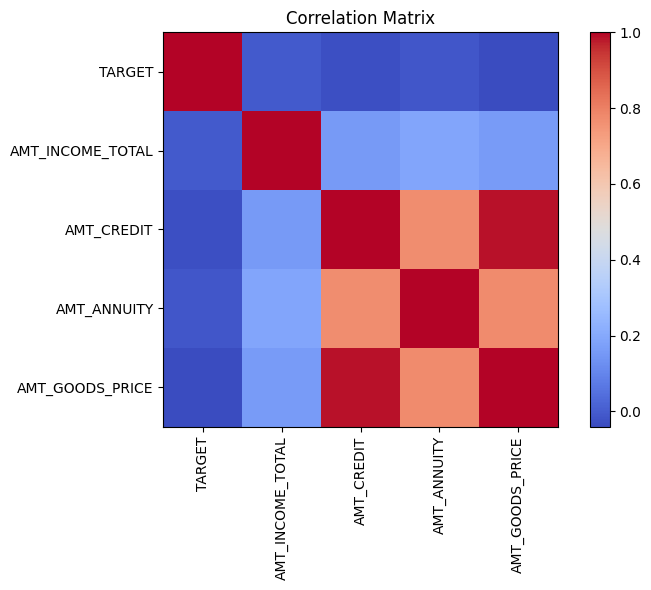

In [5]:
## Bivariate Analysis

## Relationship between Income and Loan Default.
income_target_summary = df.groupby("TARGET")["AMT_INCOME_TOTAL"].agg(["mean", "median", "std"])
income_target_summary

## Visualizing the relationship between Income and Loan Default.
income_target_summary["median"].plot(kind='bar')
plt.title("Median Income by Loan Default Status")
plt.xlabel("Loan Default Status")
plt.ylabel("Median Income")
plt.xticks([0,1], ["No Default", "Default"], rotation=0)
plt.show()

## Relationship between Age and Loan Default.
age_target = (df.assign(AGE_YEARS=age_years)
              .groupby("TARGET")["AGE_YEARS"]
              .mean())
age_target

## Visualizing the relationship between Age and Loan Default.
age_target.plot(kind="bar")
plt.title("Average age by Loan Status")
plt.xlabel("Loan Default Status")
plt.xticks([0,1], ["No Default", "Default"], rotation=0)
plt.ylabel("Average Age")
plt.show()

## Relationship between Education level and Loan Default.
education_default=df.groupby("NAME_EDUCATION_TYPE").agg(Applications=("TARGET", "size"), Defaults=("TARGET", "sum"), Default_Rate=("TARGET", "mean"))
education_default["Default_Rate"]*=100
education_default.sort_values("Default_Rate")

## Visualizing the relationship between Education level and Loan Default.
education_default["Default_Rate"].sort_values().plot(kind="barh", figsize=(8,5))
plt.title("Default Rate by Education Level")
plt.xlabel ("Default Rate (%)")
plt.show()

## Income Type with the Highest Default
income_type_default=df.groupby("NAME_INCOME_TYPE").agg(Applications=("TARGET", "size"), Defaults=("TARGET", "sum"), Default_Rate=("TARGET", "mean"))
income_type_default["Default_Rate"]*=100
income_type_default.sort_values("Default_Rate")

## Visualzing Default Rate by Income Type
income_type_default["Default_Rate"].sort_values().plot(kind="barh", figsize=(8,5))
plt.title("Default Rate by Income Type")
plt.xlabel("Default Rate (%)")
plt.show()

## Creating financial burden ratios
ratio_df = pd.DataFrame({"CREDIT_INCOME_RATIO": (df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"].replace(0, np.nan)),"ANNUITY_INCOME_RATIO": (df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"].replace(0, np.nan)), "TARGET": df["TARGET"]})
ratio_df.head()

#Checking for Infinite Values and Missing Values.
print(f"Infinite Values:\n{np.isinf(ratio_df.select_dtypes(include=np.number)).sum()}")
print(f"Missing Values:\n{ratio_df.isna().sum()}")

ratio_summary = (ratio_df.groupby("TARGET")[["CREDIT_INCOME_RATIO", "ANNUITY_INCOME_RATIO"]]    .agg(["mean", "median"]))
ratio_summary

# Default rates across financial-burden bands
ratio_df["CREDIT_INCOME_BIN"] = pd.qcut(ratio_df["CREDIT_INCOME_RATIO"],
                                        q=10,
                                        duplicates="drop")

credit_income_default_rate = (ratio_df.groupby("CREDIT_INCOME_BIN", observed=False)["TARGET"]
                              .agg(["count", "mean"]))

credit_income_default_rate["mean"] *= 100

print("Default rate by credit-to-income decile:")
display(credit_income_default_rate)

## Correlation Matrix
important = ["TARGET",
             "AMT_INCOME_TOTAL",
             "AMT_CREDIT",
             "AMT_ANNUITY",
             "AMT_GOODS_PRICE"]

corr = df[important].corr()
corr

## Visualizing the Correlation Matrix
plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm", interpolation="none")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()
